In [6]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [7]:
FILE_PATH = '../../../../cyberbullying_tweets_classifiers.csv'
df = pd.read_csv(FILE_PATH)
df = df.dropna(how='any')
df.head()

label_to_type = df.groupby('label')['type'].first().to_dict()
target_names = [label_to_type[i] for i in sorted(label_to_type.keys())]

TF-IDF Embeddings

In [4]:
base_path = "../../../../Embeddings/TF-IDF/Data"

X_train = joblib.load(os.path.join(base_path, "X_train_tfidf_2.pkl"))
X_test = joblib.load(os.path.join(base_path, "X_test_tfidf_2.pkl"))
y_train = joblib.load(os.path.join(base_path, "y_train_tfidf_2.pkl"))
y_test = joblib.load(os.path.join(base_path, "y_test_tfidf_2.pkl"))
tfidf_vectorizer = joblib.load(os.path.join(base_path,"tfidf_vectorizer.pkl"))

In [31]:
knn_model = KNeighborsClassifier(
    n_neighbors=10,        
    weights='distance',   
    metric='cosine'  
)

knn_model.fit(X_train,y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=10, weights='distance')

In [32]:
y_pred = knn_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.86      0.81      0.83      1548
           religion       0.95      0.82      0.88      1592
other_cyberbullying       0.62      0.84      0.71      1486
                age       0.95      0.90      0.93      1577
          ethnicity       0.94      0.86      0.90      1563

           accuracy                           0.85      7766
          macro avg       0.87      0.85      0.85      7766
       weighted avg       0.87      0.85      0.85      7766



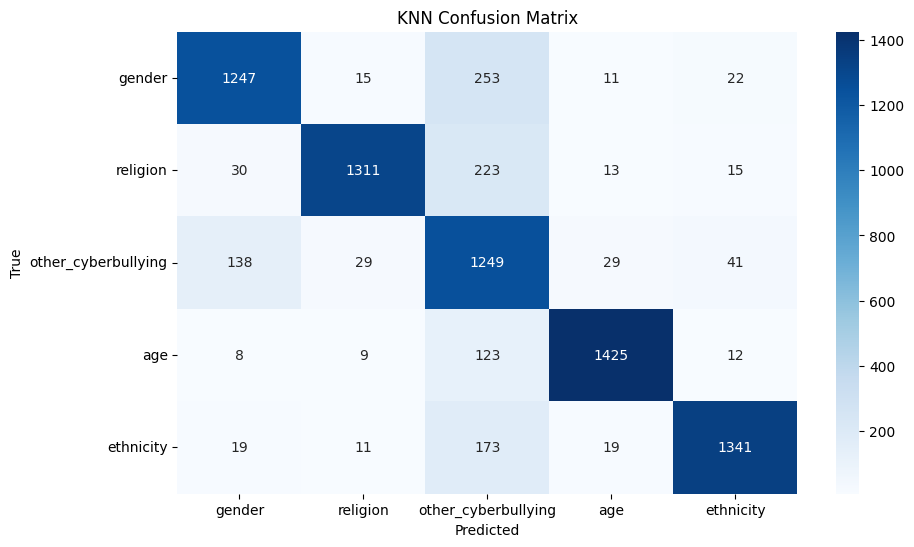

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Confusion Matrix")
plt.show()

In [35]:
joblib.dump(knn_model, 'knn_model_tfidf.pkl')

['knn_model_tfidf.pkl']

GloVE Embeddgins

In [3]:
base_path = "../../../../Embeddings/GloVe/Data"

X_train = joblib.load(os.path.join(base_path, "X_train_glove.pkl"))
X_test = joblib.load(os.path.join(base_path, "X_test_glove.pkl"))
y_train = joblib.load(os.path.join(base_path, "y_train_glove.pkl"))
y_test = joblib.load(os.path.join(base_path, "y_test_glove.pkl"))

In [4]:
knn_model = KNeighborsClassifier(
    n_neighbors=10,
    weights='distance',
    metric='cosine'
)

knn_model.fit(X_train,y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=10, weights='distance')

In [8]:
y_pred = knn_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.82      0.82      0.82      1552
           religion       0.94      0.92      0.93      1592
other_cyberbullying       0.80      0.56      0.66      1500
                age       0.87      0.98      0.92      1577
          ethnicity       0.81      0.95      0.88      1563

           accuracy                           0.85      7784
          macro avg       0.85      0.85      0.84      7784
       weighted avg       0.85      0.85      0.84      7784



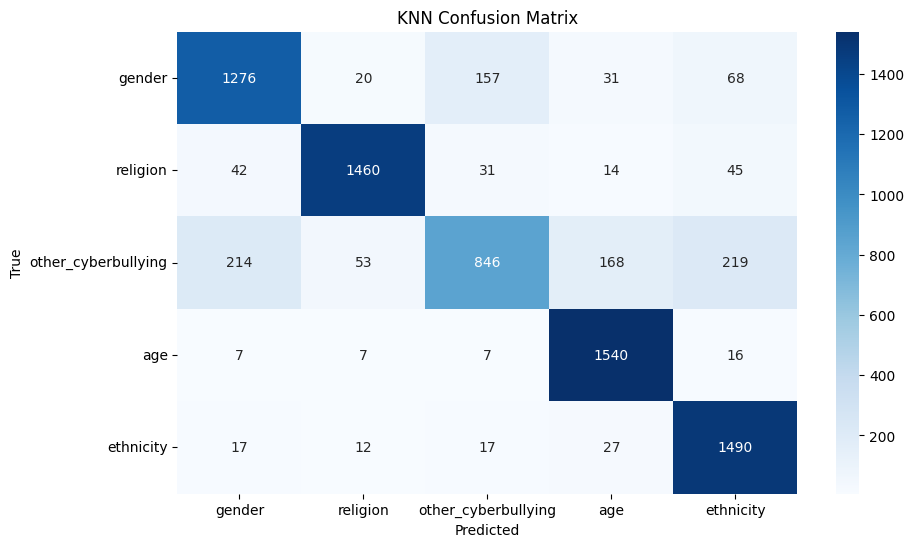

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(knn_model, 'knn_model_glove.pkl')